## Step 1: Install Libraries

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn mindspore mlxtend

## Step 2: Import Libraries

In [2]:
# Import Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Feature selection 
from sklearn.feature_selection import chi2
from sklearn.decomposition import PCA

# Supervised models 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Unsupervised model 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Association Rule Mining
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Evaluation metrics 
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# MindSpore
import mindspore as ms
from mindspore import nn, ops, Tensor

# Panda 
import pandas as pd

# Plot settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("All libraries imported successfully.")
print(f"MindSpore version: {ms.__version__}")

All libraries imported successfully.
MindSpore version: 2.8.0


## Step 3: Convert ARFF to CSV

In [3]:
def arff_to_csv(arff_path, csv_path):
    """Convert UCI ARFF file to CSV — reads @attribute for columns, @data for rows."""
    columns = []
    data_section = False
    rows = []

    with open(arff_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            if line.lower().startswith('@attribute'):
                parts = line.split()
                col_name = parts[1].strip("'\"'")
                columns.append(col_name)
            elif line.lower().startswith('@data'):
                data_section = True
            elif data_section and line:
                rows.append(line.split(','))

    df = pd.DataFrame(rows, columns=columns)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.to_csv(csv_path, index=False)

    print(f"Conversion complete!")
    print(f"  Rows    : {df.shape[0]:,}")
    print(f"  Columns : {df.shape[1]}")
    print(f"  Saved   : {csv_path}")
    return df

df = arff_to_csv(r'C:\Users\fatim\OneDrive\Desktop\Data Mining Project\phishing+websites\Training Dataset.arff', 'phishing_dataset.csv')

Conversion complete!
  Rows    : 11,055
  Columns : 31
  Saved   : phishing_dataset.csv


## TASK 2 Data Acquisition & Preprocessing
### Step 4: Load & Inspect Dataset

In [4]:
# Load the converted CSV
df = pd.read_csv('phishing_dataset.csv')

any_missing = df.isnull().values.any()

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows           : {df.shape[0]:,}")
print(f"  Columns        : {df.shape[1]}")
print(f"  Feature cols   : {df.shape[1] - 1}")
print(f"  Target column  : Result")
print(f"  Missing values : {any_missing}")
print(f"  Feature values : {sorted(df.drop('Result',axis=1).stack().unique())}")
print()
print("Feature names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

  DATASET OVERVIEW
  Rows           : 11,055
  Columns        : 31
  Feature cols   : 30
  Target column  : Result
  Missing values : False
  Feature values : [-1, 0, 1]

Feature names:
   1. having_IP_Address
   2. URL_Length
   3. Shortining_Service
   4. having_At_Symbol
   5. double_slash_redirecting
   6. Prefix_Suffix
   7. having_Sub_Domain
   8. SSLfinal_State
   9. Domain_registeration_length
  10. Favicon
  11. port
  12. HTTPS_token
  13. Request_URL
  14. URL_of_Anchor
  15. Links_in_tags
  16. SFH
  17. Submitting_to_email
  18. Abnormal_URL
  19. Redirect
  20. on_mouseover
  21. RightClick
  22. popUpWidnow
  23. Iframe
  24. age_of_domain
  25. DNSRecord
  26. web_traffic
  27. Page_Rank
  28. Google_Index
  29. Links_pointing_to_page
  30. Statistical_report
  31. Result


### Step 5: Statistical Summary & EDA

In [5]:
print("Statistical Summary:")
display(df.describe())

print("\nData types:")
print(df.dtypes.value_counts())

Statistical Summary:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Data types:
int64    31
Name: count, dtype: int64


### Step 6: Class Distribution (Balance Check)

  CLASS DISTRIBUTION
  Legitimate (+1) : 6,157  (55.7%)
  Phishing   (-1) : 4,898  (44.3%)
  Ratio           : 1.26:1
  Near-balanced   : Yes — SMOTE not required


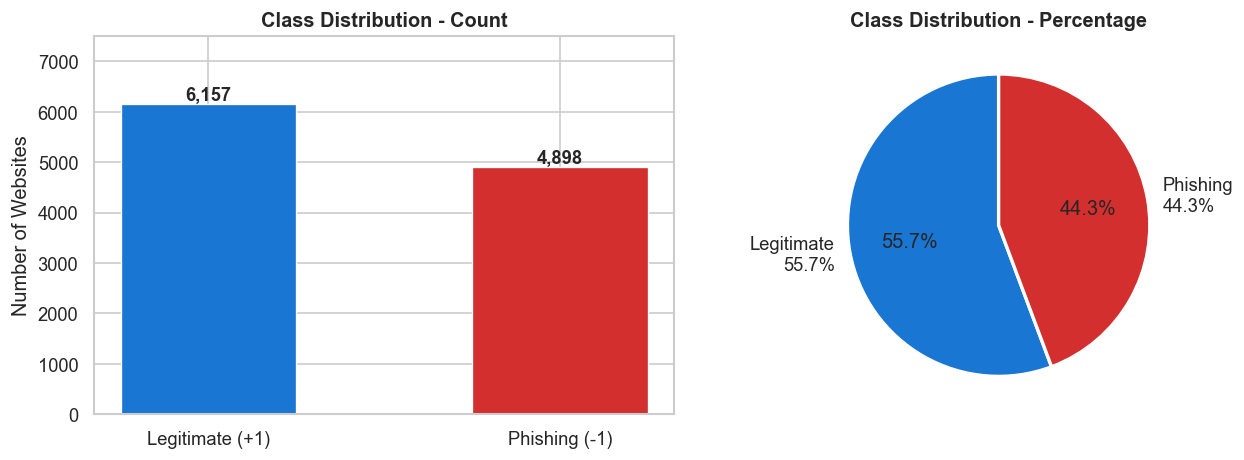

Figures 1 & 2 saved.


In [15]:
class_counts = df['Result'].value_counts()
class_pct    = df['Result'].value_counts(normalize=True) * 100

print("=" * 50)
print("  CLASS DISTRIBUTION")
print("=" * 50)
print(f"  Legitimate (+1) : {class_counts[1]:,}  ({class_pct[1]:.1f}%)")
print(f"  Phishing   (-1) : {class_counts[-1]:,}  ({class_pct[-1]:.1f}%)")
print(f"  Ratio           : {class_counts[1]/class_counts[-1]:.2f}:1")
print(f"  Near-balanced   : Yes — SMOTE not required")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(
    ['Legitimate (+1)', 'Phishing (-1)'],
    [class_counts[1], class_counts[-1]],
    color=['#1976D2', '#D32F2F'],
    edgecolor='white', linewidth=0.8, width=0.5
)
axes[0].set_title('Class Distribution - Count', fontweight='bold')
axes[0].set_ylabel('Number of Websites')
for bar, val in zip(bars, [class_counts[1], class_counts[-1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 80,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 7500)

axes[1].pie(
    [class_counts[1], class_counts[-1]],
    labels=['Legitimate\n55.7%', 'Phishing\n44.3%'],
    colors=['#1976D2', '#D32F2F'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution - Percentage', fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_2_class_distribution.png', bbox_inches='tight')
plt.show()
print("Figures 1 & 2 saved.")

### Step 7: Correlation Heatmap

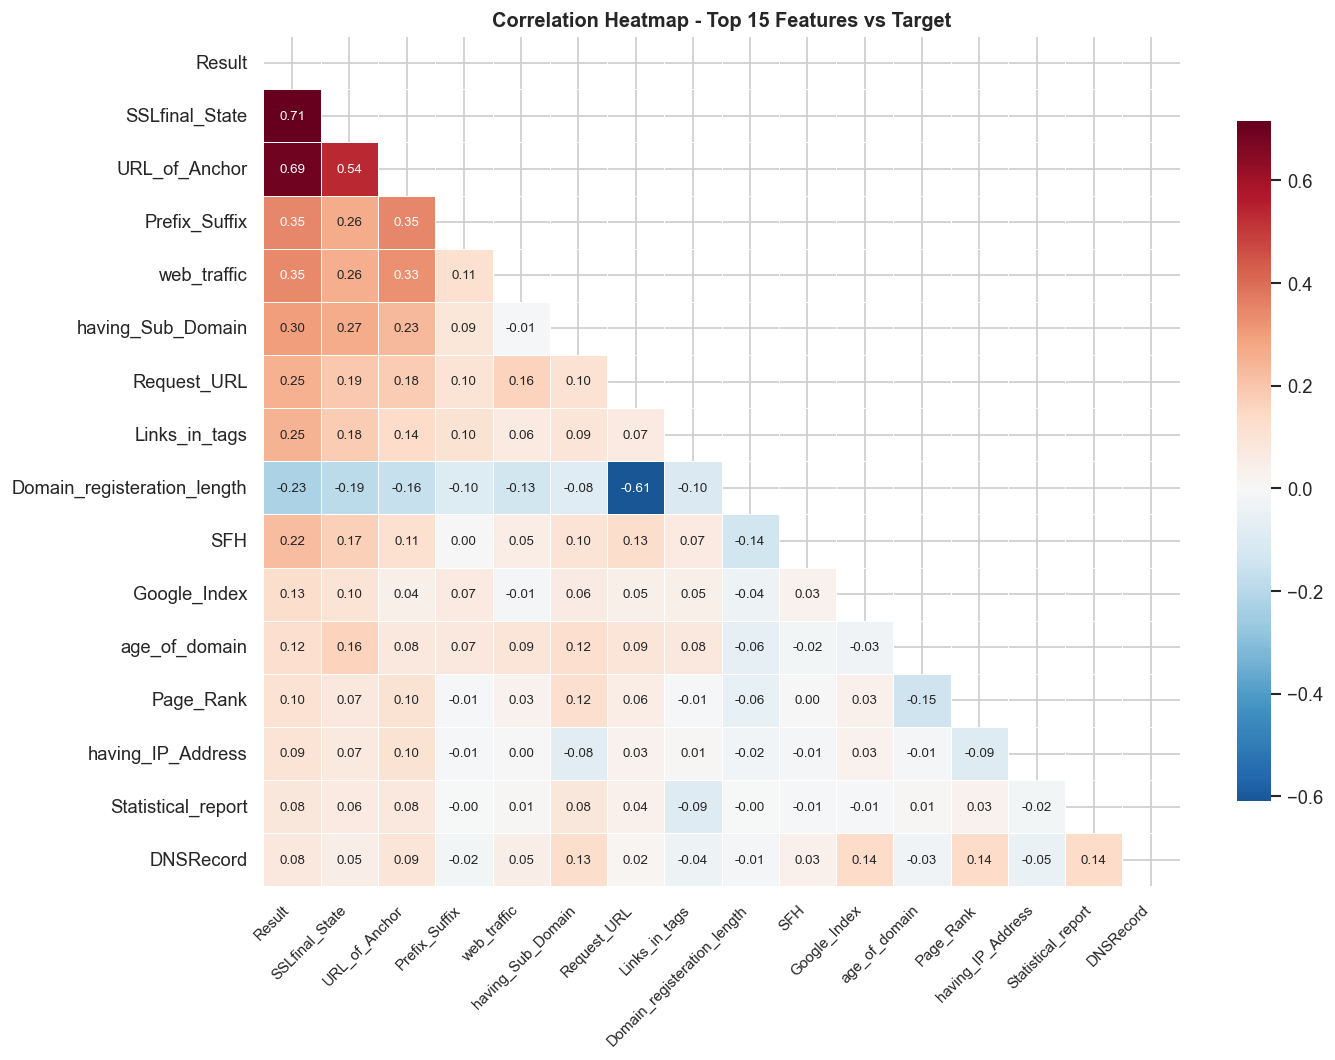

Figure 3 saved.


In [16]:
top15_corr  = df.corr()['Result'].abs().nlargest(16).index
corr_matrix = df[top15_corr].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 8}
)
plt.title('Correlation Heatmap - Top 15 Features vs Target',
          fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

### Step 8: Preprocessing: Split, Scale, Train/Test

In [17]:
# 1. Separate features and target
X = df.drop('Result', axis=1)
y = df['Result']

print(f"Features (X) : {X.shape}")
print(f"Target   (y) : {y.shape}")

Features (X) : (11055, 30)
Target   (y) : (11055,)


In [18]:
# 2. Train/test split 80/20 — stratified 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set  : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Stratified: Yes — class balance preserved")


Train set : 8,844 rows (80%)
Test set  : 2,211 rows  (20%)
Stratified: Yes — class balance preserved


In [19]:
# 3. StandardScaler
# Applied to KNN and K-Means (distance-based algorithms)
# Decision Tree does NOT need scaling (rule-based, scale-invariant)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nStandardScaler applied:")
print(f"  Before — mean: {X_train.iloc[:,0].mean():.4f}")
print(f"  After  — mean: {X_train_scaled[:,0].mean():.4f}")
print(f"  After  — std : {X_train_scaled[:,0].std():.4f}")
print()
print("Note: X_train / X_test used for Decision Tree (unscaled).")
print("      X_train_scaled / X_test_scaled used for KNN and K-Means.")


StandardScaler applied:
  Before — mean: 0.3180
  After  — mean: 0.0000
  After  — std : 1.0000

Note: X_train / X_test used for Decision Tree (unscaled).
      X_train_scaled / X_test_scaled used for KNN and K-Means.


### Step 9: Feature Engineering
Following Week 7-8: *"Create brand-new features using domain knowledge"*

We engineer two new features from existing URL-based attributes:
- **URL_Risk_Score** sum of negative URL indicators (IP, shortening, @ symbol, double slash)
- **Domain_Trust_Score** sum of positive domain credibility indicators (age, DNS, PageRank, traffic)

Feature Engineering complete.
  URL_Risk_Score     range: 0 - 5
  Domain_Trust_Score range: 0 - 5


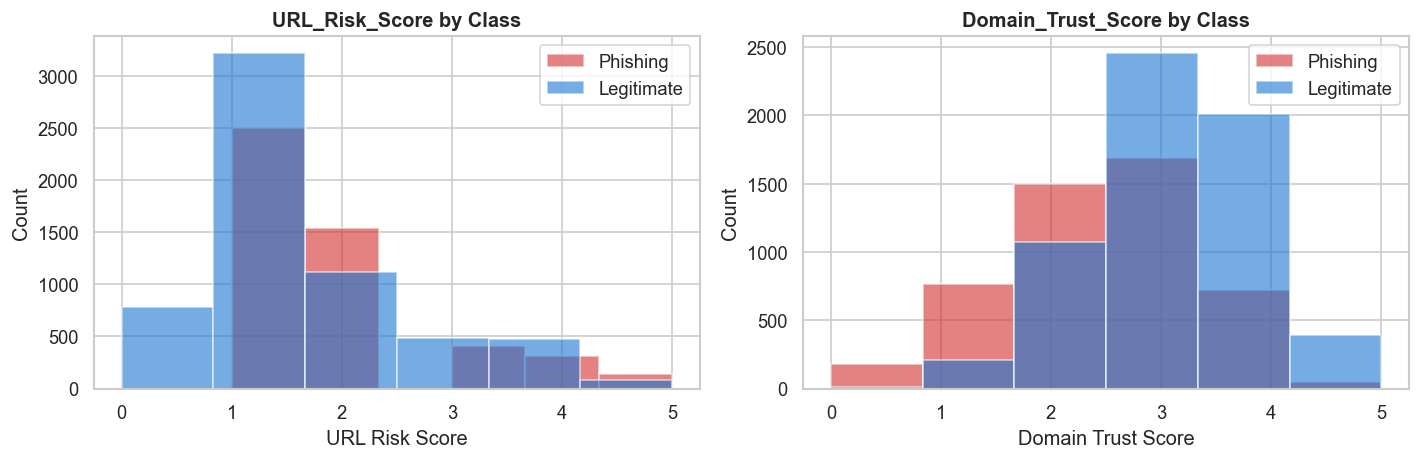

Figures 4 & 5 saved.


In [20]:
# Feature Engineering
# Create new features from existing domain knowledge

df_eng = df.copy()

# URL_Risk_Score: count of features that indicate phishing URL structure
# -1 means phishing indicator for these features
risk_features = [
    'having_IP_Address', 'Shortining_Service',
    'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix'
]
# Count how many risk features are -1 (phishing signal)
df_eng['URL_Risk_Score'] = (df_eng[risk_features] == -1).sum(axis=1)

# Domain_Trust_Score: count of features that indicate a trusted domain
# +1 means legitimate indicator for these features
trust_features = [
    'age_of_domain', 'DNSRecord', 'Page_Rank',
    'web_traffic', 'Google_Index'
]
df_eng['Domain_Trust_Score'] = (df_eng[trust_features] == 1).sum(axis=1)

print("Feature Engineering complete.")
print(f"  URL_Risk_Score     range: {df_eng['URL_Risk_Score'].min()} - {df_eng['URL_Risk_Score'].max()}")
print(f"  Domain_Trust_Score range: {df_eng['Domain_Trust_Score'].min()} - {df_eng['Domain_Trust_Score'].max()}")

# Visualise engineered features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, color, label in [(-1, '#D32F2F', 'Phishing'), (1, '#1976D2', 'Legitimate')]:
    subset = df_eng[df_eng['Result'] == cls]
    axes[0].hist(subset['URL_Risk_Score'], alpha=0.6, color=color,
                 label=label, bins=6, edgecolor='white')
    axes[1].hist(subset['Domain_Trust_Score'], alpha=0.6, color=color,
                 label=label, bins=6, edgecolor='white')

axes[0].set_title('URL_Risk_Score by Class', fontweight='bold')
axes[0].set_xlabel('URL Risk Score')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].set_title('Domain_Trust_Score by Class', fontweight='bold')
axes[1].set_xlabel('Domain Trust Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_5_engineered_features.png', bbox_inches='tight')
plt.show()
print("Figures 4 & 5 saved.")

## TASK 3 Feature Selection, Learning Methods & Evaluation

### Step 10: Chi-Square Feature Selection
Following Week 7-8 and Week 8-9:
> *"H₀: Feature is INDEPENDENT of outcome - H₁: Feature is RELATED to outcome"*
> *"If χ² is large (p-value < 0.05), the feature IS important. Keep it!"*

In [21]:
# Chi-Square requires non-negative values
# Shift -1,0,1 → 0,1,2
X_shifted = X + 1

# H₀: feature is independent of target (Result)
# H₁: feature is related to target (Result)
chi2_scores, p_values = chi2(X_shifted, y)

chi2_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Chi2_Score' : chi2_scores.round(3),
    'P_Value'    : p_values.round(6)
}).sort_values('Chi2_Score', ascending=False).reset_index(drop=True)

chi2_df['Rank']        = range(1, 31)
chi2_df['Selected']    = chi2_df['Rank'] <= 15
chi2_df['Significant'] = chi2_df['P_Value'] < 0.05
chi2_df['Decision']    = chi2_df['Significant'].map({True: 'KEEP ✓', False: 'DROP ✗'})

print("=" * 75)
print("  H₀: Feature is INDEPENDENT of whether a website is phishing or legitimate")
print("  H₁: Feature is RELATED to the target class")
print("  Threshold: p-value < 0.05 → Reject H₀ → Feature is significant → KEEP")
print("=" * 75)
display(chi2_df[['Rank','Feature','Chi2_Score','P_Value','Significant','Decision']])

top15 = chi2_df[chi2_df['Selected']]['Feature'].tolist()
print(f"\nTop 15 features selected by Chi-Square:")
print(top15)

  H₀: Feature is INDEPENDENT of whether a website is phishing or legitimate
  H₁: Feature is RELATED to the target class
  Threshold: p-value < 0.05 → Reject H₀ → Feature is significant → KEEP


,Rank,Feature,Chi2_Score,P_Value,Significant,Decision
0,1,SSLfinal_State,3753.809,0.000000,True,KEEP ✓
1,2,URL_of_Anchor,2939.401,0.000000,True,KEEP ✓
2,3,Prefix_Suffix,2330.866,0.000000,True,KEEP ✓
3,4,SFH,772.583,0.000000,True,KEEP ✓
4,5,Domain_registeration_length,753.395,0.000000,True,KEEP ✓
5,6,web_traffic,704.749,0.000000,True,KEEP ✓
6,7,having_Sub_Domain,617.968,0.000000,True,KEEP ✓
7,8,Request_URL,577.136,0.000000,True,KEEP ✓
8,9,Links_in_tags,450.793,0.000000,True,KEEP ✓
9,10,Page_Rank,179.611,0.000000,True,KEEP ✓



Top 15 features selected by Chi-Square:
['SSLfinal_State', 'URL_of_Anchor', 'Prefix_Suffix', 'SFH', 'Domain_registeration_length', 'web_traffic', 'having_Sub_Domain', 'Request_URL', 'Links_in_tags', 'Page_Rank', 'age_of_domain', 'having_IP_Address', 'URL_Length', 'Google_Index', 'DNSRecord']


### Step 11: Chi-Square Visualisation

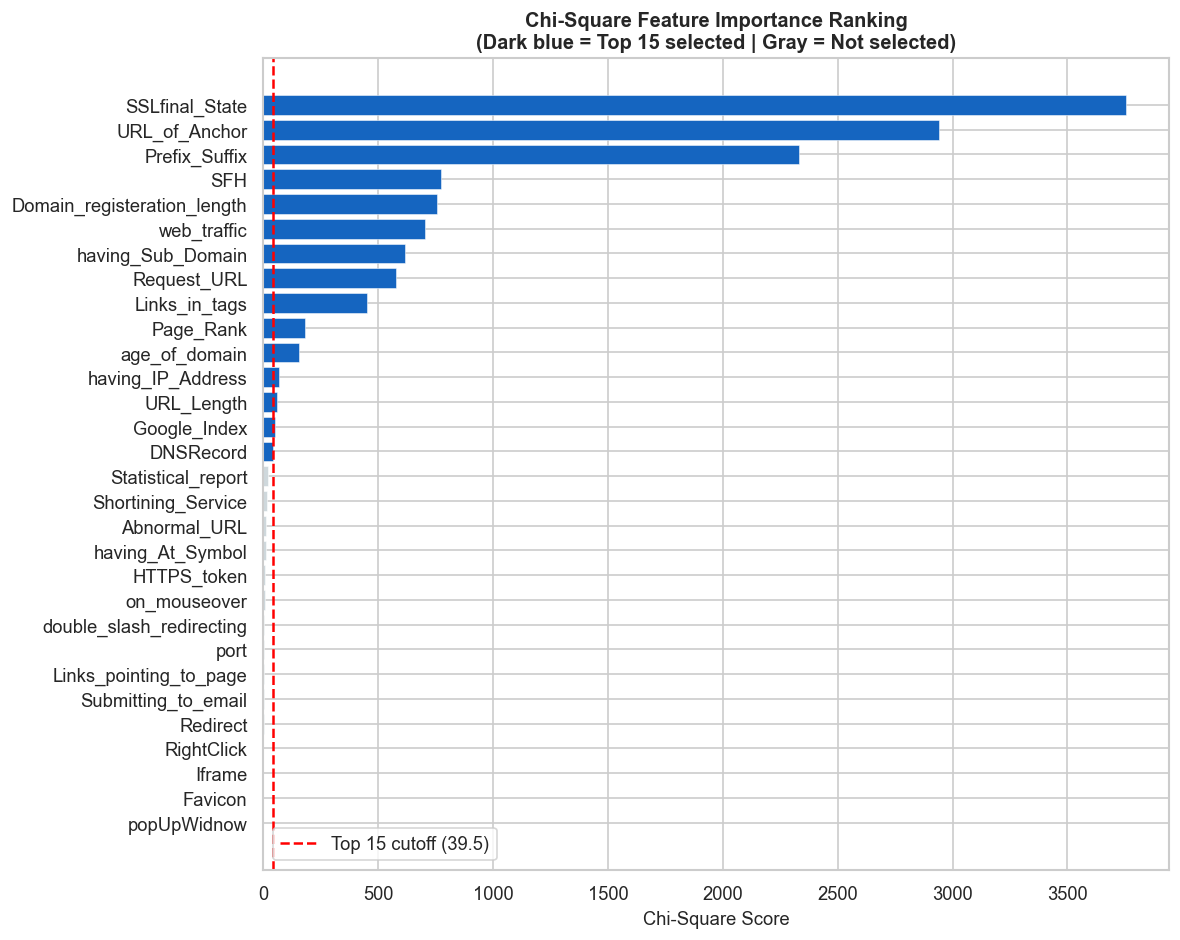

Figure 6 saved.


In [22]:
plt.figure(figsize=(10, 8))

colors = ['#1565C0' if i < 15 else '#CFD8DC' for i in range(30)]
plt.barh(
    chi2_df['Feature'][::-1],
    chi2_df['Chi2_Score'][::-1],
    color=colors[::-1], edgecolor='white', linewidth=0.3
)

cutoff = chi2_df['Chi2_Score'].iloc[14]
plt.axvline(x=cutoff, color='red', linestyle='--',
            linewidth=1.5, label=f'Top 15 cutoff ({cutoff:.1f})')
plt.xlabel('Chi-Square Score', fontsize=11)
plt.title(
    'Chi-Square Feature Importance Ranking\n'
    '(Dark blue = Top 15 selected | Gray = Not selected)',
    fontweight='bold'
)
plt.legend()
plt.tight_layout()
plt.savefig('fig6_chi2_feature_selection.png', bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

### Step 12: PCA Feature Extraction
Following Week 7-8: *"Feature Extraction - Transform high-dimensional data into compact representations"*

PCA is also used later to visualise K-Means clusters in 2D.

PCA Analysis:
  Total features          : 30
  Components for 95% var  : 23
  Components for 90% var  : 19

Top 5 components explained variance:
  PC1: 17.86%
  PC2: 13.60%
  PC3: 8.72%
  PC4: 5.27%
  PC5: 4.79%


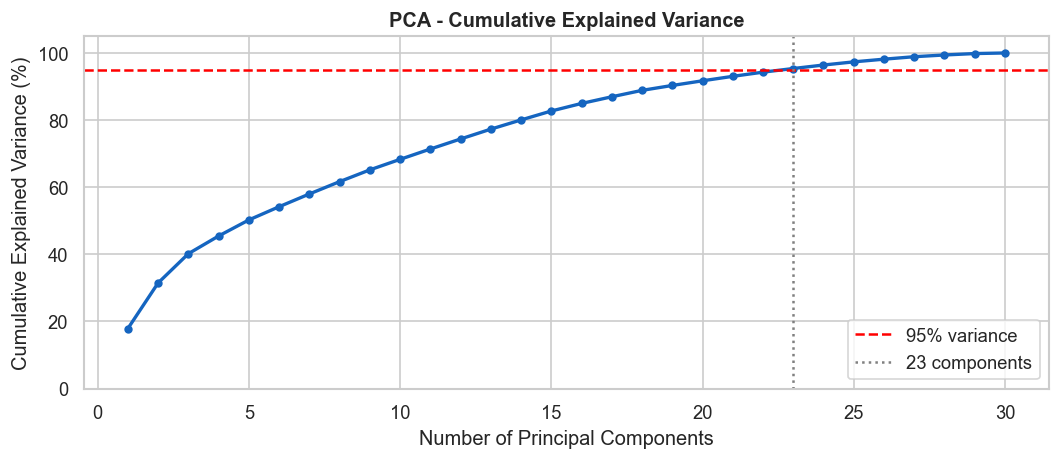

Figure 7 saved.


In [23]:
# PCA on full scaled dataset
X_all_scaled = StandardScaler().fit_transform(X)
pca_full     = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_all_scaled)

# Cumulative explained variance
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

# How many components explain 95% variance?
n_95 = np.argmax(cumulative_var >= 95) + 1

print(f"PCA Analysis:")
print(f"  Total features          : 30")
print(f"  Components for 95% var  : {n_95}")
print(f"  Components for 90% var  : {np.argmax(cumulative_var >= 90) + 1}")
print()
print("Top 5 components explained variance:")
for i, v in enumerate(pca_full.explained_variance_ratio_[:5], 1):
    print(f"  PC{i}: {v*100:.2f}%")

plt.figure(figsize=(9, 4))
plt.plot(range(1, 31), cumulative_var,
         marker='o', color='#1565C0', linewidth=2, markersize=4)
plt.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95% variance')
plt.axvline(x=n_95, color='gray', linestyle=':', linewidth=1.5,
            label=f'{n_95} components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA - Cumulative Explained Variance', fontweight='bold')
plt.legend()
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig('fig7_pca_variance.png', bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

### Step 13: Prepare Feature-Selected Datasets

In [24]:
# Feature-selected sets (top 15 from Chi-Square)
X_train_fs = X_train[top15]
X_test_fs  = X_test[top15]

scaler_fs      = StandardScaler()
X_train_fs_sc  = scaler_fs.fit_transform(X_train_fs)
X_test_fs_sc   = scaler_fs.transform(X_test_fs)

print(f"Full feature set     : {X_train.shape[1]} features")
print(f"Selected feature set : {X_train_fs.shape[1]} features")
print(f"Top 15 features:")
for i, f in enumerate(top15, 1):
    print(f"  {i:2d}. {f}")

Full feature set     : 30 features
Selected feature set : 15 features
Top 15 features:
   1. SSLfinal_State
   2. URL_of_Anchor
   3. Prefix_Suffix
   4. SFH
   5. Domain_registeration_length
   6. web_traffic
   7. having_Sub_Domain
   8. Request_URL
   9. Links_in_tags
  10. Page_Rank
  11. age_of_domain
  12. having_IP_Address
  13. URL_Length
  14. Google_Index
  15. DNSRecord


### Step 14: Evaluation Helper Functions

In [26]:
def evaluate_model(name, y_test, y_pred):
    """Print all evaluation metrics and return results dict."""
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=-1, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=-1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=-1, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"{'='*55}")
    print(f"  Model     : {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%  ← priority metric")
    print(f"  F1-Score  : {f1*100:.2f}%")
    print()
    print(classification_report(
        y_test, y_pred,
        target_names=['Phishing (-1)', 'Legitimate (+1)'],
        zero_division=0
    ))
    return {'name': name, 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1': f1, 'cm': cm}


def plot_confusion_matrix(cm, model_name, fig_num):
    """Plot a labelled confusion matrix."""
    labels = ['Phishing\n(-1)', 'Legitimate\n(+1)']
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, cbar=False,
        annot_kws={'size': 16, 'weight': 'bold'}
    )
    plt.title(f'Confusion Matrix - {model_name}', fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fname = f'fig{fig_num}_cm_{model_name.replace(" ","_").lower()}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f"Figure {fig_num} saved.")

all_results = []
print("Helper functions ready.")

Helper functions ready.


### Step 15 : KNN Classifier (Default k=5)
**Why KNN?** Distance-based classifier (Week 3). Uses Euclidean distance — StandardScaler ensures fair distance calculation across all 30 features. Addresses curse of dimensionality via Chi-Square feature selection.

  Model     : KNN - Default (k=5)
  Accuracy  : 94.89%
  Precision : 94.74%
  Recall    : 93.67%  ← priority metric
  F1-Score  : 94.20%

                 precision    recall  f1-score   support

  Phishing (-1)       0.95      0.94      0.94       980
Legitimate (+1)       0.95      0.96      0.95      1231

       accuracy                           0.95      2211
      macro avg       0.95      0.95      0.95      2211
   weighted avg       0.95      0.95      0.95      2211



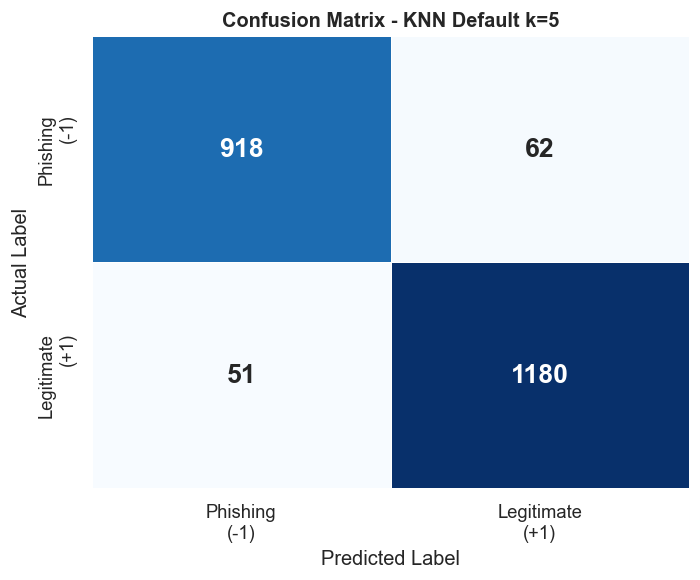

Figure 8 saved.


In [27]:
# KNN uses SCALED data
knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train_scaled, y_train)
y_pred_knn_default = knn_default.predict(X_test_scaled)

res = evaluate_model('KNN - Default (k=5)', y_test, y_pred_knn_default)
all_results.append(res)
plot_confusion_matrix(res['cm'], 'KNN Default k=5', 8)

### Step 16: Decision Tree Classifier (Default)
**Why Decision Tree?** Rule-based classifier (Week 3). Interpretable - creates readable if-then rules. Scale-invariant, so unscaled data is used.

  Model     : Decision Tree - Default
  Accuracy  : 97.11%
  Precision : 97.22%
  Recall    : 96.22%  ← priority metric
  F1-Score  : 96.72%

                 precision    recall  f1-score   support

  Phishing (-1)       0.97      0.96      0.97       980
Legitimate (+1)       0.97      0.98      0.97      1231

       accuracy                           0.97      2211
      macro avg       0.97      0.97      0.97      2211
   weighted avg       0.97      0.97      0.97      2211



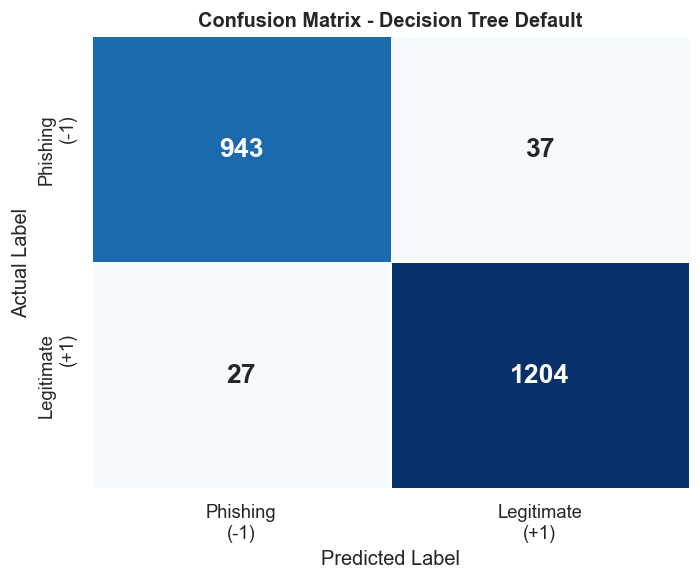

Figure 9 saved.


In [28]:
# Decision Tree uses UNSCALED data
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)
y_pred_dt_default = dt_default.predict(X_test)

res = evaluate_model('Decision Tree - Default', y_test, y_pred_dt_default)
all_results.append(res)
plot_confusion_matrix(res['cm'], 'Decision Tree Default', 9)

### Step 17: Decision Tree Structure Visualisation

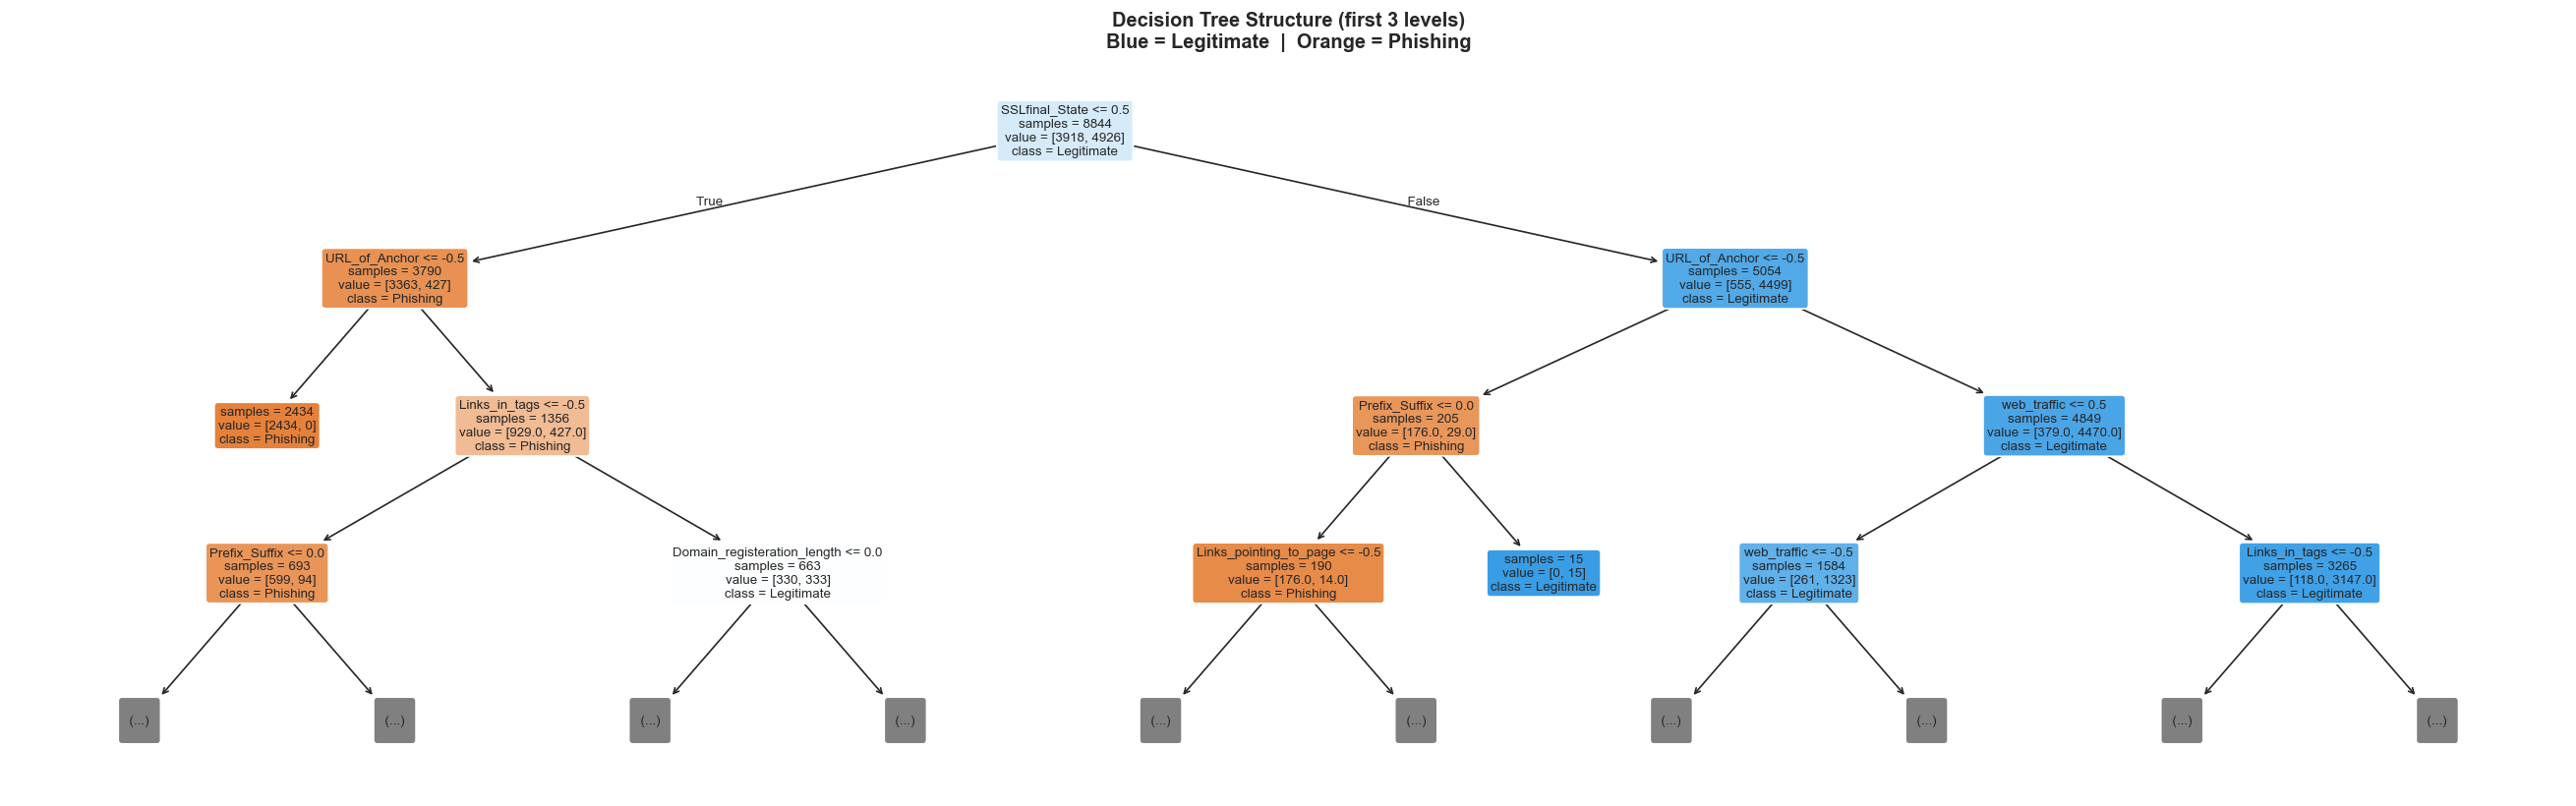

Figure 10 saved.


In [29]:
plt.figure(figsize=(22, 7))
plot_tree(
    dt_default, max_depth=3,
    feature_names=list(X.columns),
    class_names=['Phishing', 'Legitimate'],
    filled=True, rounded=True, fontsize=8, impurity=False
)
plt.title(
    'Decision Tree Structure (first 3 levels)\n'
    'Blue = Legitimate  |  Orange = Phishing',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig('fig10_decision_tree_structure.png', bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

## TASK 4 Hyperparameter Tuning

### Step 18: KNN Tuning: k = 3, 5, 7, 9, 11

In [30]:
k_values   = [3, 5, 7, 9, 11]
knn_tuning = []

print("=" * 62)
print(f"  {'k':<6} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>9}")
print("-" * 62)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=-1, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=-1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=-1, zero_division=0)

    knn_tuning.append({'k': k, 'accuracy': acc,
                       'precision': prec, 'recall': rec, 'f1': f1})
    print(f"  {k:<6} {acc*100:>9.2f}% {prec*100:>10.2f}% {rec*100:>8.2f}% {f1*100:>8.2f}%")

print("-" * 62)
knn_df = pd.DataFrame(knn_tuning)
best_k = int(knn_df.loc[knn_df['f1'].idxmax(), 'k'])
print(f"\n  Best k = {best_k} (highest F1-Score)")

  k        Accuracy   Precision    Recall        F1
--------------------------------------------------------------
  3          94.93%      95.21%    93.27%    94.23%
  5          94.89%      94.74%    93.67%    94.20%
  7          94.53%      94.60%    92.96%    93.77%
  9          94.39%      94.40%    92.86%    93.62%
  11         94.08%      93.45%    93.16%    93.31%
--------------------------------------------------------------

  Best k = 3 (highest F1-Score)


### Step 19: KNN Tuning Plot

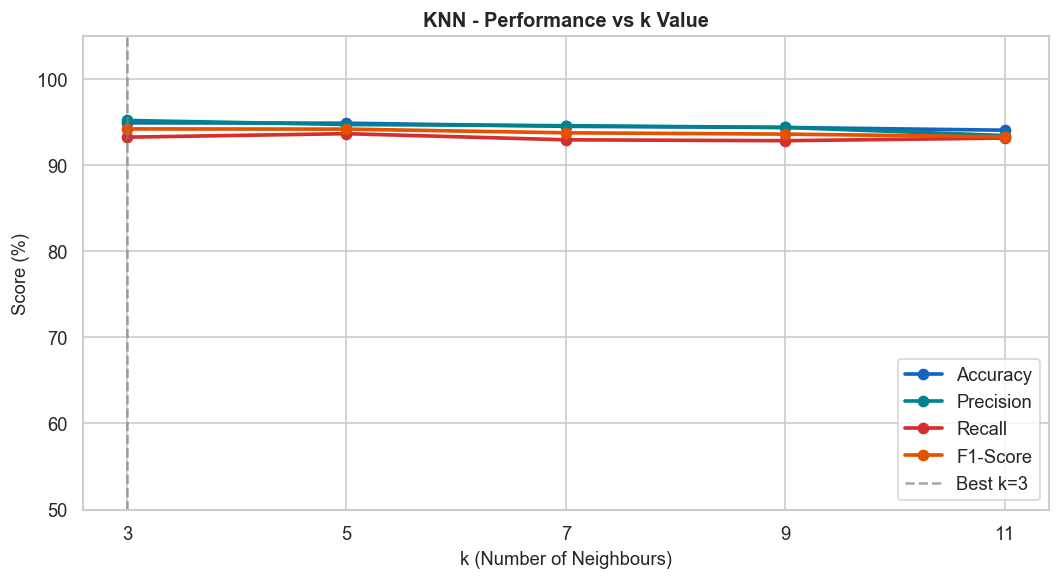

Figure 11 saved.


In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
metric_cfg = [
    ('accuracy',  '#1565C0', 'Accuracy'),
    ('precision', '#00838F', 'Precision'),
    ('recall',    '#D32F2F', 'Recall'),
    ('f1',        '#E65100', 'F1-Score'),
]
for col, color, label in metric_cfg:
    ax.plot(knn_df['k'], knn_df[col]*100,
            marker='o', color=color, label=label, linewidth=2.2)

ax.axvline(x=best_k, color='gray', linestyle='--',
           linewidth=1.5, label=f'Best k={best_k}', alpha=0.7)
ax.set_xlabel('k (Number of Neighbours)', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('KNN - Performance vs k Value', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xticks(k_values)
ax.set_ylim(50, 105)
plt.tight_layout()
plt.savefig('fig11_knn_tuning.png', bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

### Step 20: Final Tuned KNN Model

  Model     : KNN - Tuned (k=3)
  Accuracy  : 94.93%
  Precision : 95.21%
  Recall    : 93.27%  ← priority metric
  F1-Score  : 94.23%

                 precision    recall  f1-score   support

  Phishing (-1)       0.95      0.93      0.94       980
Legitimate (+1)       0.95      0.96      0.95      1231

       accuracy                           0.95      2211
      macro avg       0.95      0.95      0.95      2211
   weighted avg       0.95      0.95      0.95      2211



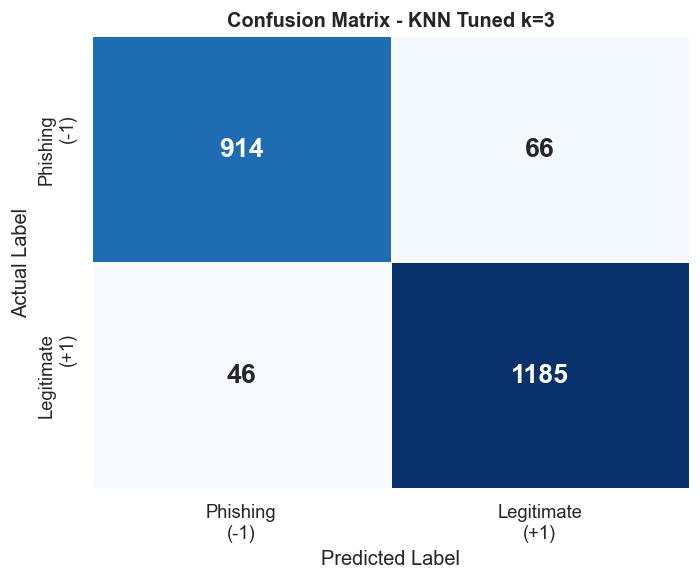

Figure 12 saved.


In [32]:
knn_tuned = KNeighborsClassifier(n_neighbors=best_k)
knn_tuned.fit(X_train_scaled, y_train)
y_pred_knn_tuned = knn_tuned.predict(X_test_scaled)

res = evaluate_model(f'KNN - Tuned (k={best_k})', y_test, y_pred_knn_tuned)
all_results.append(res)
plot_confusion_matrix(res['cm'], f'KNN Tuned k={best_k}', 12)

### Step 21: Decision Tree Tuning: max_depth = 3, 5, 7, None

In [33]:
depth_values = [3, 5, 7, None]
dt_tuning    = []

print("=" * 68)
print(f"  {'max_depth':<12} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>9}")
print("-" * 68)

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=-1, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=-1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=-1, zero_division=0)

    dt_tuning.append({'max_depth': str(depth), 'accuracy': acc,
                      'precision': prec, 'recall': rec, 'f1': f1})
    label = str(depth) if depth is not None else 'None (full)'
    print(f"  {label:<12} {acc*100:>9.2f}% {prec*100:>10.2f}% {rec*100:>8.2f}% {f1*100:>8.2f}%")

print("-" * 68)
dt_df        = pd.DataFrame(dt_tuning)
best_idx     = dt_df['f1'].idxmax()
best_depth   = dt_df.loc[best_idx, 'max_depth']
best_depth_v = None if best_depth == 'None' else int(best_depth)
print(f"\n  Best max_depth = {best_depth} (highest F1-Score)")

  max_depth      Accuracy   Precision    Recall        F1
--------------------------------------------------------------------
  3                90.77%      96.97%    81.73%    88.70%
  5                92.67%      94.85%    88.27%    91.44%
  7                93.76%      93.76%    92.04%    92.89%
  None (full)      97.11%      97.22%    96.22%    96.72%
--------------------------------------------------------------------

  Best max_depth = None (highest F1-Score)


### Step 22: Decision Tree Tuning Plot

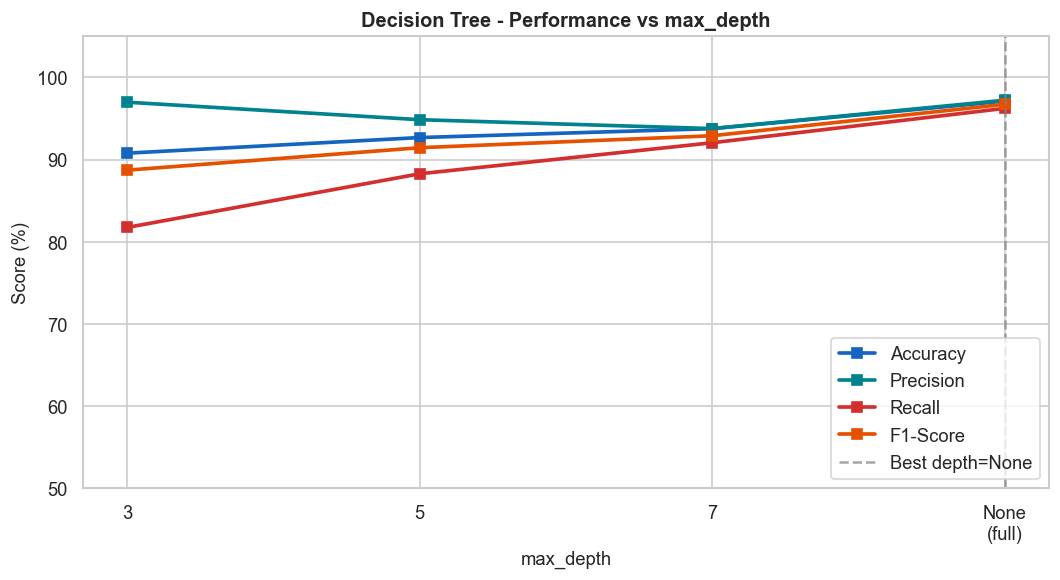

Figure 13 saved.


In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos    = range(len(depth_values))
x_labels = ['3', '5', '7', 'None\n(full)']

for col, color, label in metric_cfg:
    ax.plot(x_pos, dt_df[col]*100,
            marker='s', color=color, label=label, linewidth=2.2)

ax.axvline(x=best_idx, color='gray', linestyle='--',
           linewidth=1.5, label=f'Best depth={best_depth}', alpha=0.7)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Decision Tree - Performance vs max_depth', fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(50, 105)
plt.tight_layout()
plt.savefig('fig13_dt_tuning.png', bbox_inches='tight')
plt.show()
print("Figure 13 saved.")

### Step 23: Final Tuned Decision Tree Model

  Model     : Decision Tree - Tuned (depth=None)
  Accuracy  : 97.11%
  Precision : 97.22%
  Recall    : 96.22%  ← priority metric
  F1-Score  : 96.72%

                 precision    recall  f1-score   support

  Phishing (-1)       0.97      0.96      0.97       980
Legitimate (+1)       0.97      0.98      0.97      1231

       accuracy                           0.97      2211
      macro avg       0.97      0.97      0.97      2211
   weighted avg       0.97      0.97      0.97      2211



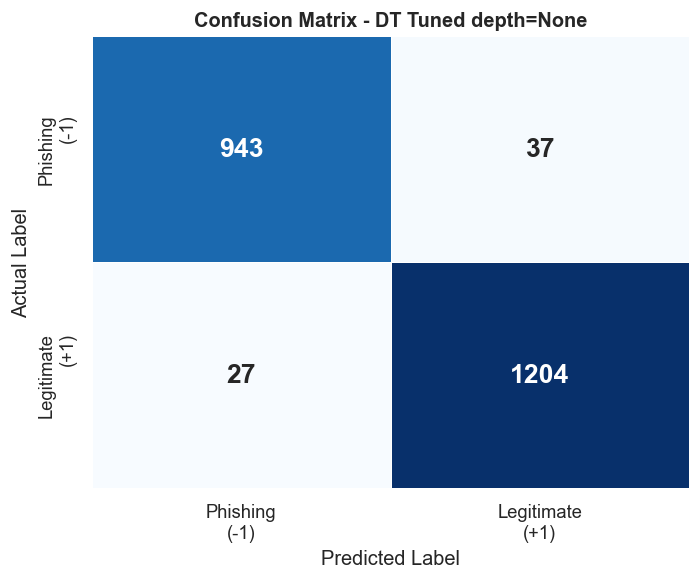

Figure 14 saved.


In [35]:
dt_tuned = DecisionTreeClassifier(max_depth=best_depth_v, random_state=RANDOM_STATE)
dt_tuned.fit(X_train, y_train)
y_pred_dt_tuned = dt_tuned.predict(X_test)

res = evaluate_model(f'Decision Tree - Tuned (depth={best_depth})', y_test, y_pred_dt_tuned)
all_results.append(res)
plot_confusion_matrix(res['cm'], f'DT Tuned depth={best_depth}', 14)

### Step 24: Decision Tree Feature Importance

Top 15 features by Decision Tree importance:


,Feature,Importance
0,SSLfinal_State,0.622178
1,URL_of_Anchor,0.112638
2,Links_in_tags,0.036755
3,having_Sub_Domain,0.034653
4,web_traffic,0.026071
5,Domain_registeration_length,0.019539
6,Links_pointing_to_page,0.017991
7,Prefix_Suffix,0.017737
8,Request_URL,0.012996
9,age_of_domain,0.012030


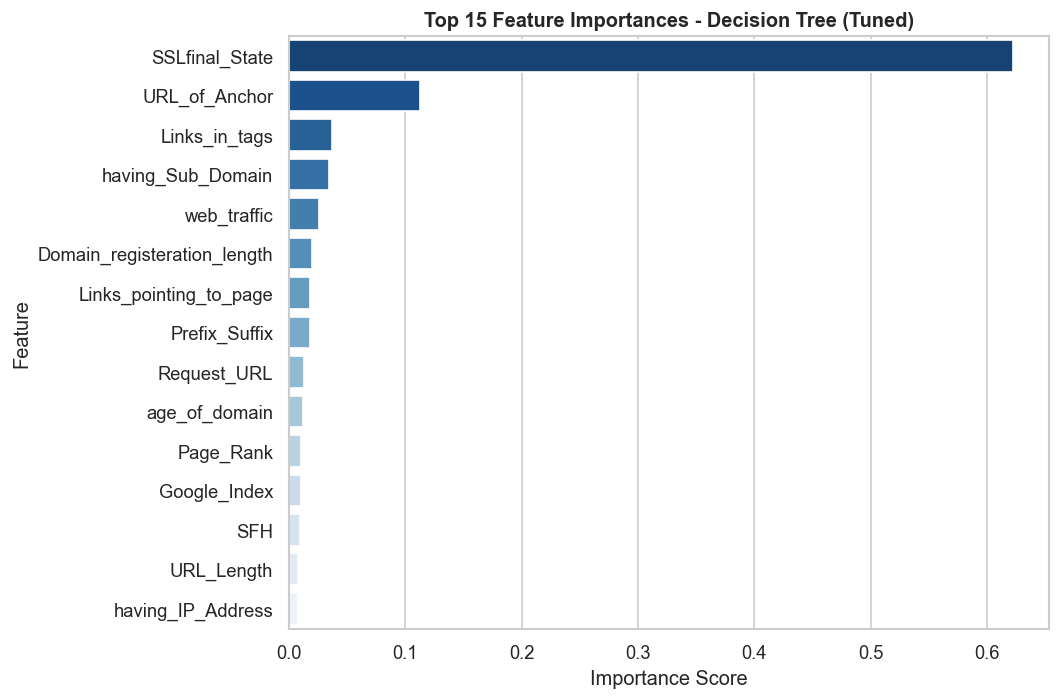

Figure 15 saved.


In [37]:
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': dt_tuned.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

print("Top 15 features by Decision Tree importance:")
display(feat_imp.reset_index(drop=True))

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp, y='Feature', x='Importance',
            palette='Blues_r', edgecolor='white')
plt.title('Top 15 Feature Importances - Decision Tree (Tuned)',
          fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig15_feature_importance_dt.png', bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

### Step 25: K-Means Clustering (Unsupervised)
Following Week 4-5: *"K-Means groups data into K clusters based on feature similarity..  NO prior labels"*

Goal: discover whether the algorithm can separate phishing from legitimate websites without labels.

In [38]:
X_all_scaled = StandardScaler().fit_transform(X)
inertia      = []
sil_scores   = []
k_range      = range(2, 11)

print("Running Elbow Method and Silhouette Score...")
print(f"{'k':>4}  {'Inertia':>12}  {'Silhouette':>12}")
print("-" * 35)

for k in k_range:
    km       = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_all_scaled)
    inertia.append(km.inertia_)
    sil      = silhouette_score(X_all_scaled, labels_k,
                                sample_size=3000, random_state=RANDOM_STATE)
    sil_scores.append(sil)
    print(f"{k:>4}  {km.inertia_:>12.1f}  {sil:>12.4f}")

print("\nDone.")

Running Elbow Method and Silhouette Score...
   k       Inertia    Silhouette
-----------------------------------
   2      282208.8        0.2760
   3      246378.7        0.2811
   4      229464.2        0.1105
   5      220639.0        0.1095
   6      212849.0        0.1009
   7      206524.8        0.1064
   8      202934.8        0.1024
   9      197075.8        0.1018
  10      194546.1        0.0936

Done.


### Step 26:  Elbow & Silhouette Plots

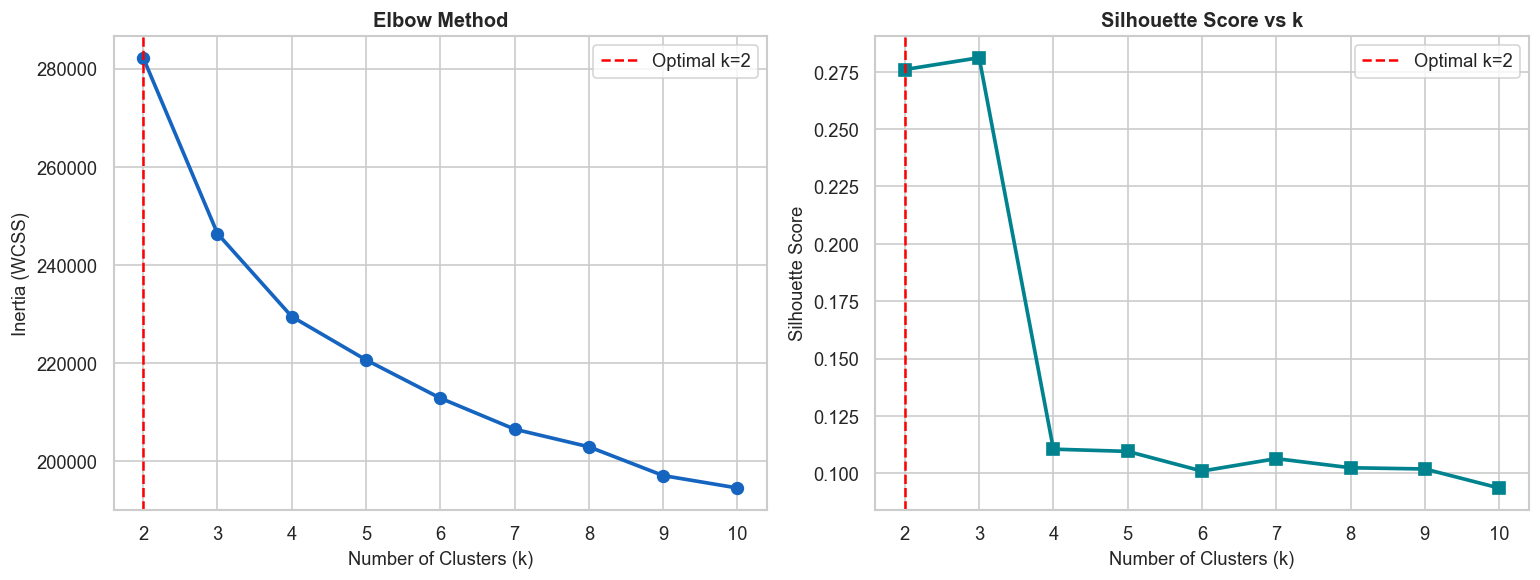

Figures 16 & 17 saved.

Conclusion: k=2 is optimal — matches the binary structure of the dataset.


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertia, marker='o',
             color='#1565C0', linewidth=2.2, markersize=7)
axes[0].axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='Optimal k=2')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=11)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, marker='s',
             color='#00838F', linewidth=2.2, markersize=7)
axes[1].axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='Optimal k=2')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.tight_layout()
plt.savefig('fig16_17_elbow_silhouette.png', bbox_inches='tight')
plt.show()
print("Figures 16 & 17 saved.")
print(f"\nConclusion: k=2 is optimal — matches the binary structure of the dataset.")

### Step 27: Final K-Means Model (k=2) + Cluster Analysis

In [40]:
kmeans         = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_all_scaled)
sil_final      = silhouette_score(X_all_scaled, cluster_labels)

df_c = df.copy()
df_c['Cluster'] = cluster_labels

print("=" * 50)
print("  K-MEANS RESULTS (k=2)")
print("=" * 50)
print(f"  Silhouette Score : {sil_final:.4f}")
print()

for c in [0, 1]:
    sub   = df_c[df_c['Cluster'] == c]
    total = len(sub)
    legit = (sub['Result'] == 1).sum()
    phish = (sub['Result'] == -1).sum()
    dom   = 'Legitimate' if legit > phish else 'Phishing'
    purity = max(legit, phish) / total
    print(f"  Cluster {c} - {total:,} websites | Purity: {purity:.3f}")
    print(f"    Legitimate : {legit:,} ({legit/total*100:.1f}%)")
    print(f"    Phishing   : {phish:,} ({phish/total*100:.1f}%)")
    print(f"    Dominant   : {dom}")
    print()

  K-MEANS RESULTS (k=2)
  Silhouette Score : 0.2795

  Cluster 0 - 9,182 websites | Purity: 0.562
    Legitimate : 5,156 (56.2%)
    Phishing   : 4,026 (43.8%)
    Dominant   : Legitimate

  Cluster 1 - 1,873 websites | Purity: 0.534
    Legitimate : 1,001 (53.4%)
    Phishing   : 872 (46.6%)
    Dominant   : Legitimate



### Step 28: K-Means PCA Scatter Plot (2D Visualisation)

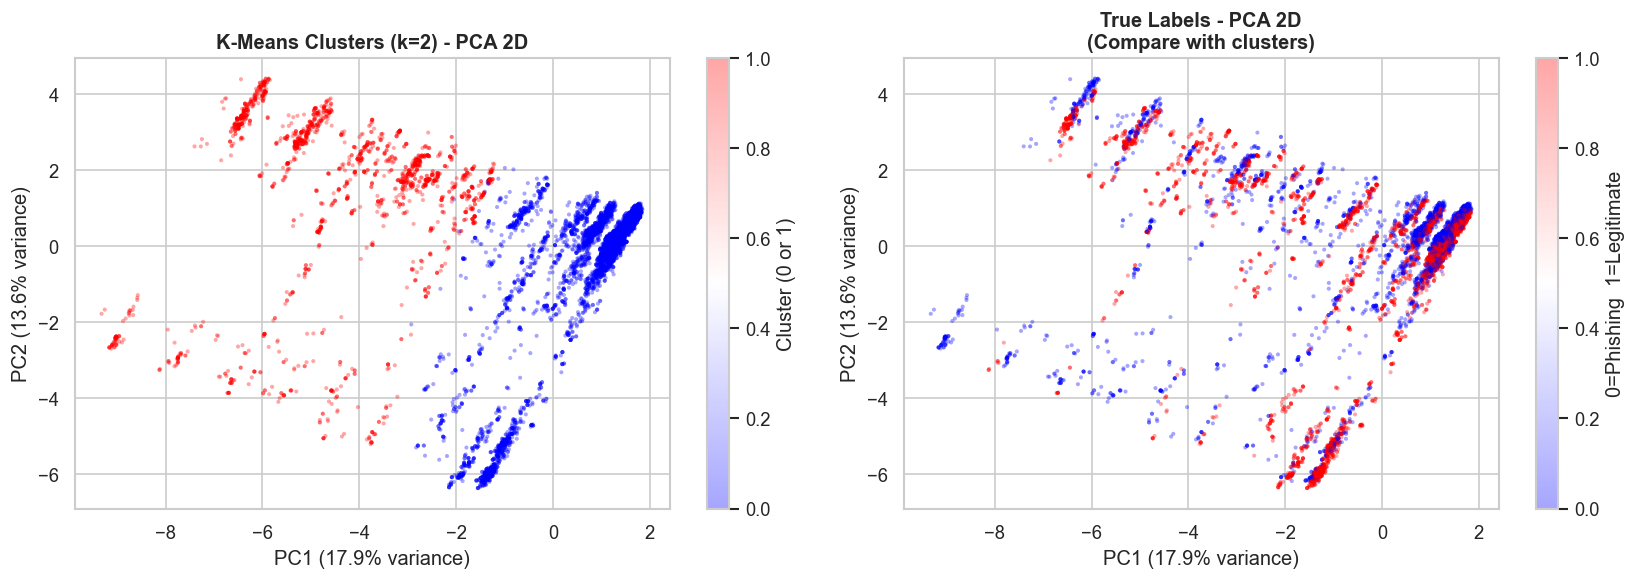

Figures 18 & 19 saved.


In [41]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all_scaled)
var1  = pca.explained_variance_ratio_[0]*100
var2  = pca.explained_variance_ratio_[1]*100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1],
                       c=cluster_labels, cmap='bwr',
                       alpha=0.35, s=6, linewidths=0)
axes[0].set_title('K-Means Clusters (k=2) - PCA 2D', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var2:.1f}% variance)')
plt.colorbar(sc1, ax=axes[0], label='Cluster (0 or 1)')

true_c = [0 if v == -1 else 1 for v in y.values]
sc2 = axes[1].scatter(X_pca[:,0], X_pca[:,1],
                       c=true_c, cmap='bwr',
                       alpha=0.35, s=6, linewidths=0)
axes[1].set_title('True Labels - PCA 2D\n(Compare with clusters)',
                  fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}% variance)')
plt.colorbar(sc2, ax=axes[1], label='0=Phishing  1=Legitimate')

plt.tight_layout()
plt.savefig('fig18_19_kmeans_pca.png', bbox_inches='tight')
plt.show()
print("Figures 18 & 19 saved.")

### Step 29: Association Rule Mining (Apriori)
Following Week 4-5: *"Apriori mines frequent itemsets Association rules: If A then B"*

**Note:** Apriori requires transactional/binary data. We convert our features to binary (phishing signal = 1, otherwise 0) to find which phishing URL features frequently co-occur.

In [42]:
# Convert features to binary - 1 if feature indicates phishing (-1 in original), else 0
# This creates a transaction-like binary matrix for Apriori

# Select only phishing rows to find co-occurring phishing indicators
phishing_subset = df[df['Result'] == -1].drop('Result', axis=1)

# Convert: -1 → True (phishing indicator present), else False
binary_df = (phishing_subset == -1).astype(bool)

print(f"Phishing transactions for Apriori: {len(binary_df):,}")
print(f"Features (items)                 : {binary_df.shape[1]}")
print()

# Run Apriori — find frequent phishing feature combinations
# min_support=0.3 means feature appears in at least 30% of phishing sites
frequent_itemsets = apriori(
    binary_df,
    min_support=0.3,
    use_colnames=True,
    max_len=3
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Frequent itemsets found : {len(frequent_itemsets)}")
print()
print("Top 10 most frequent itemsets (phishing feature combinations):")
display(
    frequent_itemsets.sort_values('support', ascending=False)
    .head(10)[['support','itemsets','length']]
    .reset_index(drop=True)
)

Phishing transactions for Apriori: 4,898
Features (items)                 : 30

Frequent itemsets found : 128

Top 10 most frequent itemsets (phishing feature combinations):


,support,itemsets,length
0,1.000000,frozenset({Prefix_Suffix}),1
1,0.865251,"frozenset({Prefix_Suffix, SFH})",2
2,0.865251,frozenset({SFH}),1
3,0.832789,frozenset({URL_Length}),1
4,0.832789,"frozenset({URL_Length, Prefix_Suffix})",2
5,0.793181,"frozenset({Page_Rank, Prefix_Suffix})",2
6,0.793181,frozenset({Page_Rank}),1
7,0.771131,"frozenset({URL_Length, Prefix_Suffix, SFH})",3
8,0.771131,"frozenset({URL_Length, SFH})",2
9,0.686607,"frozenset({URL_Length, Page_Rank})",2


### Step 30: Extract Association Rules

Association rules generated : 209

Top 10 rules by Lift (Lift > 1 = positive correlation):


,antecedents,consequents,support,confidence,lift
0,frozenset({age_of_domain}),"frozenset({SSLfinal_State, Prefix_Suffix})",0.403226,0.750380,1.204641
1,"frozenset({Prefix_Suffix, age_of_domain})",frozenset({SSLfinal_State}),0.403226,0.750380,1.204641
2,frozenset({age_of_domain}),frozenset({SSLfinal_State}),0.403226,0.750380,1.204641
3,"frozenset({URL_Length, age_of_domain})",frozenset({SSLfinal_State}),0.355860,0.739813,1.187678
4,"frozenset({age_of_domain, SFH})",frozenset({SSLfinal_State}),0.345651,0.738656,1.185820
5,frozenset({DNSRecord}),"frozenset({Page_Rank, Prefix_Suffix})",0.325439,0.927823,1.169750
6,"frozenset({DNSRecord, Prefix_Suffix})",frozenset({Page_Rank}),0.325439,0.927823,1.169750
7,frozenset({DNSRecord}),frozenset({Page_Rank}),0.325439,0.927823,1.169750
8,"frozenset({age_of_domain, SFH})",frozenset({URL_Length}),0.445488,0.952007,1.143155
9,frozenset({URL_Length}),"frozenset({Page_Rank, SFH})",0.642915,0.772003,1.127391


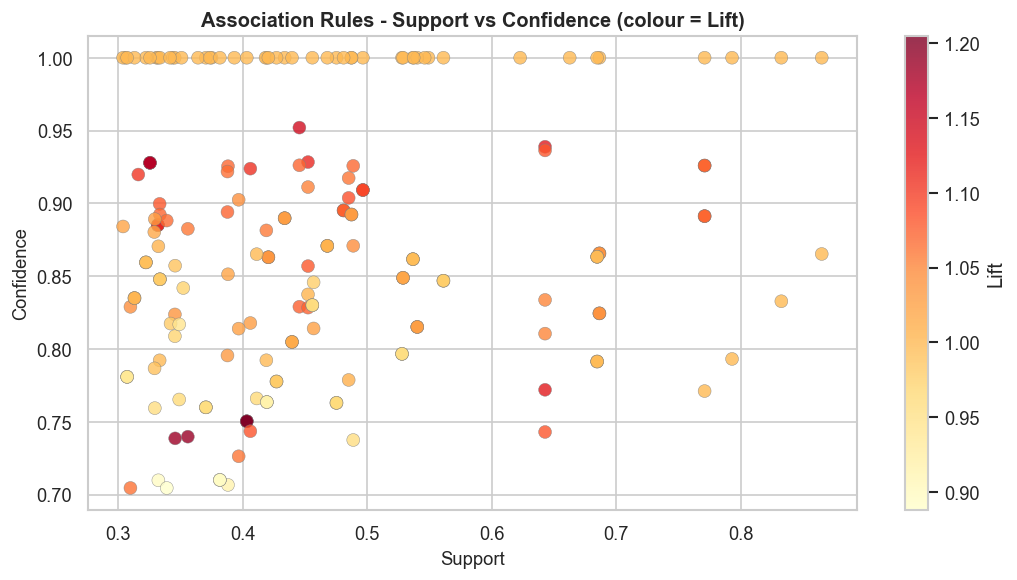

Figure 20 saved.


In [43]:
# Generate association rules with min_confidence=0.7
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.7
)
rules = rules.sort_values('lift', ascending=False)

print(f"Association rules generated : {len(rules)}")
print()
print("Top 10 rules by Lift (Lift > 1 = positive correlation):")
display(
    rules[['antecedents','consequents','support','confidence','lift']]
    .head(10)
    .reset_index(drop=True)
)

# Visualise support vs confidence
if len(rules) > 0:
    plt.figure(figsize=(9, 5))
    scatter = plt.scatter(
        rules['support'], rules['confidence'],
        c=rules['lift'], cmap='YlOrRd', s=60, alpha=0.8, edgecolors='gray', linewidths=0.3
    )
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support', fontsize=11)
    plt.ylabel('Confidence', fontsize=11)
    plt.title('Association Rules - Support vs Confidence (colour = Lift)',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig20_association_rules.png', bbox_inches='tight')
    plt.show()
    print("Figure 20 saved.")

## Final Comparison All Supervised Models

### Step 31: Model Comparison Table

In [44]:
comp = pd.DataFrame([{
    'Model'    : r['name'],
    'Accuracy' : f"{r['accuracy']*100:.2f}%",
    'Precision': f"{r['precision']*100:.2f}%",
    'Recall'   : f"{r['recall']*100:.2f}%",
    'F1-Score' : f"{r['f1']*100:.2f}%",
} for r in all_results])

print("=" * 80)
print("  FINAL MODEL COMPARISON TABLE")
print("=" * 80)
display(comp)

best = max(all_results, key=lambda r: r['f1'])
print(f"\nBest model    : {best['name']}")
print(f"Best F1-Score : {best['f1']*100:.2f}%")
print(f"Best Recall   : {best['recall']*100:.2f}%")

  FINAL MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score
0,KNN - Default (k=5),94.89%,94.74%,93.67%,94.20%
1,Decision Tree - Default,97.11%,97.22%,96.22%,96.72%
2,KNN - Tuned (k=3),94.93%,95.21%,93.27%,94.23%
3,Decision Tree - Tuned (depth=None),97.11%,97.22%,96.22%,96.72%



Best model    : Decision Tree - Default
Best F1-Score : 96.72%
Best Recall   : 96.22%


### Step 32: Model Comparison Chart

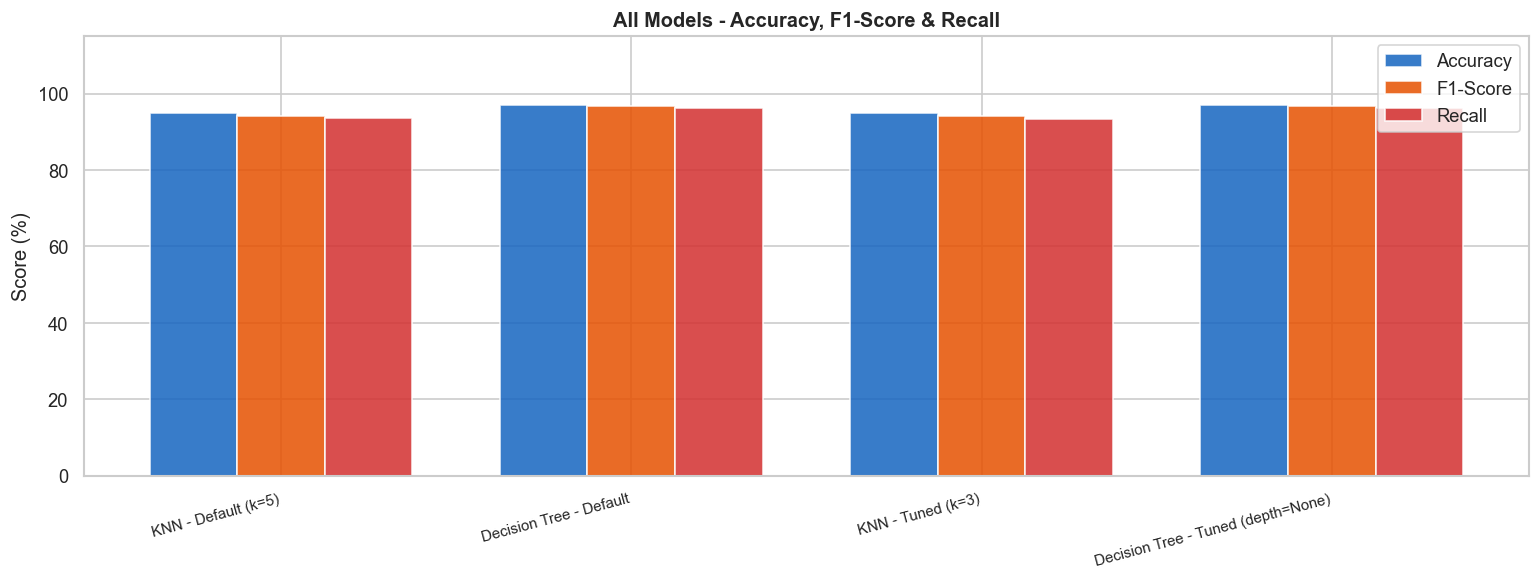

Figure 21 saved.


In [45]:
fig, ax = plt.subplots(figsize=(13, 5))

names = [r['name'] for r in all_results]
accs  = [r['accuracy']*100 for r in all_results]
f1s   = [r['f1']*100       for r in all_results]
recs  = [r['recall']*100   for r in all_results]

x     = np.arange(len(names))
width = 0.25

ax.bar(x - width, accs, width, label='Accuracy',
       color='#1565C0', alpha=0.85, edgecolor='white')
ax.bar(x,          f1s,  width, label='F1-Score',
       color='#E65100', alpha=0.85, edgecolor='white')
ax.bar(x + width,  recs, width, label='Recall',
       color='#D32F2F', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('All Models - Accuracy, F1-Score & Recall',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig21_model_comparison.png', bbox_inches='tight')
plt.show()
print("Figure 21 saved.")

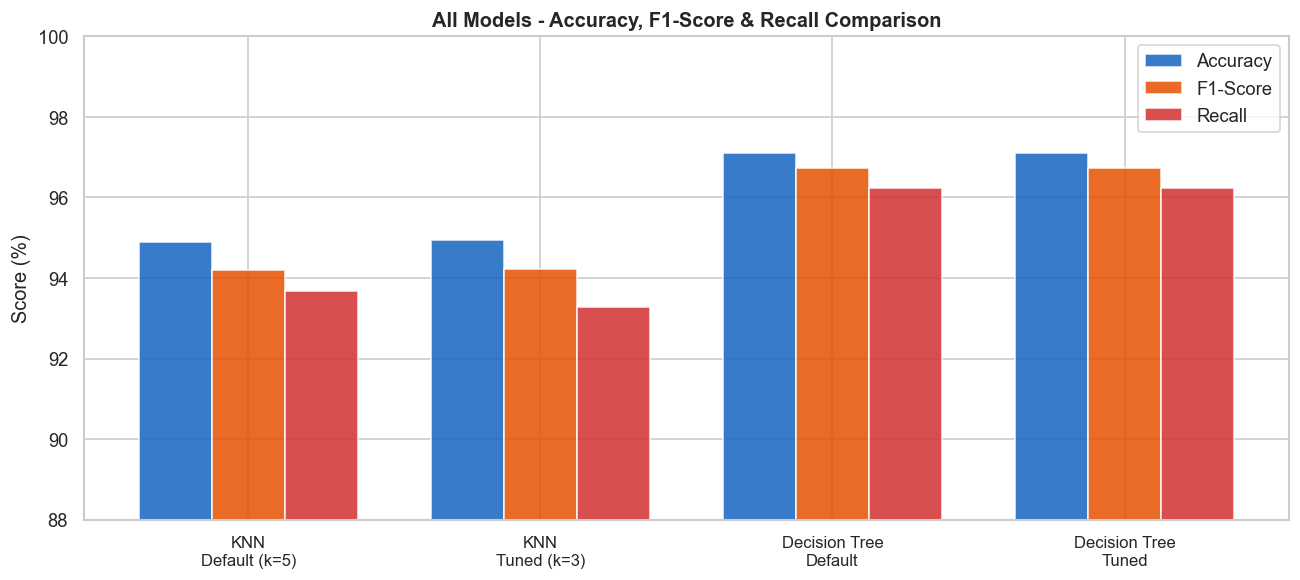

Clean Figure 22 saved.


In [46]:
# Clean comparison chart - 4 unique models only
import matplotlib.pyplot as plt
import numpy as np

clean_results = [
    {'name': 'KNN\nDefault (k=5)',     'accuracy': 94.89, 'f1': 94.20, 'recall': 93.67},
    {'name': 'KNN\nTuned (k=3)',       'accuracy': 94.93, 'f1': 94.23, 'recall': 93.27},
    {'name': 'Decision Tree\nDefault', 'accuracy': 97.11, 'f1': 96.72, 'recall': 96.22},
    {'name': 'Decision Tree\nTuned',   'accuracy': 97.11, 'f1': 96.72, 'recall': 96.22},
]

names = [r['name'] for r in clean_results]
accs  = [r['accuracy'] for r in clean_results]
f1s   = [r['f1']       for r in clean_results]
recs  = [r['recall']   for r in clean_results]

x     = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, accs, width, label='Accuracy',  color='#1565C0', alpha=0.85, edgecolor='white')
ax.bar(x,          f1s,  width, label='F1-Score',  color='#E65100', alpha=0.85, edgecolor='white')
ax.bar(x + width,  recs, width, label='Recall',    color='#D32F2F', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(88, 100)
ax.set_title('All Models - Accuracy, F1-Score & Recall Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig22_clean_model_comparison.png', bbox_inches='tight')
plt.show()
print("Clean Figure 22 saved.")

## Migration to MindSpore
### Following Lab Manual: MindSpore for Classification on Structured CSV Data

> This section migrates the project to **MindSpore** (Huawei AI Framework), earning the
> *"Project migration to a new tool/technology"* component (5 marks).
> The pipeline follows the exact lab manual structure for CSV classification.

### Step 33: Verify MindSpore

In [47]:
import mindspore
print(mindspore.__version__)
mindspore.run_check()

2.8.0
MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [CPU] successfully!


### Step 34: MindSpore Imports & Load Data

In [48]:
# Classification using MLP on CSV data - Phishing Website Detection
# Migration from scikit-learn to MindSpore
# Following lab manual: MindSpore for Autism Classification on Structured CSV Data

import pandas as pd
import numpy as np
import mindspore as ms
from mindspore import nn, ops, Tensor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# =========================
# 1. Load and preprocess CSV
# =========================
csv_path = "phishing_dataset.csv"
df_ms    = pd.read_csv(csv_path)

any_missing = df_ms.isnull().values.any()
print(f"Dataset shape : {df_ms.shape}")
print(f"\nAre there any missing values in the file? {any_missing}")
print(f"\nClass distribution:")
print(df_ms['Result'].value_counts())
print(f"\nFirst 5 rows:")
print(df_ms.head())

X_ms = df_ms.iloc[:, :-1].values
y_ms = df_ms.iloc[:, -1].values

print(f"\nFeatures shape : {X_ms.shape}")
print(f"Target shape   : {y_ms.shape}")
print(f"Unique labels  : {np.unique(y_ms)}")

Dataset shape : (11055, 31)

Are there any missing values in the file? False

Class distribution:
Result
 1    6157
-1    4898
Name: count, dtype: int64

First 5 rows:
   having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1  

### Step 35: Label Encoding, Scaling, Tensor Conversion

In [49]:
# Encode labels if categorical
if y_ms.dtype == object or isinstance(y_ms[0], str):
    le = LabelEncoder()
    y_ms = le.fit_transform(y_ms)
else:
    le = LabelEncoder()
    y_ms = le.fit_transform(y_ms)

print(f"Labels after encoding: {np.unique(y_ms)}")
print(f"  0 = Phishing  |  1 = Legitimate")

# Standardize features
scaler_ms = StandardScaler()
X_ms = scaler_ms.fit_transform(X_ms)
print(f"\nStandardScaler applied - mean=0, std=1")

# Train-test split
X_train_ms, X_test_ms, y_train_ms, y_test_ms = train_test_split(
    X_ms, y_ms, test_size=0.2, random_state=42
)

print(f"\nTrain-test split (80/20):")
print(f"  Training set : {X_train_ms.shape[0]:,} rows")
print(f"  Test set     : {X_test_ms.shape[0]:,} rows")

# Convert to MindSpore Tensors
X_train_ms = Tensor(X_train_ms, ms.float32)
y_train_ms = Tensor(y_train_ms, ms.int32)
X_test_ms  = Tensor(X_test_ms,  ms.float32)
y_test_ms  = Tensor(y_test_ms,  ms.int32)

print(f"\nData after split - Training set")
print("************************************\n")
print(X_train_ms, y_train_ms)
print("Data after split - Test set")
print("************************************\n")
print(X_test_ms)

Labels after encoding: [0 1]
  0 = Phishing  |  1 = Legitimate

StandardScaler applied - mean=0, std=1

Train-test split (80/20):
  Training set : 8,844 rows
  Test set     : 2,211 rows

Data after split - Training set
************************************

[[ 0.7227087  -0.47881627  0.38761386 ...  0.40215373 -0.60360795
   0.40382183]
 [-1.3836833  -0.47881627  0.38761386 ... -2.4866114  -0.60360795
   0.40382183]
 [ 0.7227087   2.1319427   0.38761386 ... -2.4866114  -0.60360795
   0.40382183]
 ...
 [-1.3836833   2.1319427   0.38761386 ...  0.40215373 -0.60360795
   0.40382183]
 [ 0.7227087  -0.47881627  0.38761386 ...  0.40215373 -0.60360795
  -2.4763396 ]
 [-1.3836833   2.1319427   0.38761386 ...  0.40215373 -0.60360795
   0.40382183]] [1 0 1 ... 0 1 0]
Data after split - Test set
************************************

[[-1.3836833  -0.47881627  0.38761386 ...  0.40215373  1.1510293
   0.40382183]
 [-1.3836833  -0.47881627  0.38761386 ...  0.40215373 -2.3582454
   0.40382183]
 [-1.38

### Step 36: Create Dataset Loader

In [50]:
# =========================
# 2. Define Dataset Loader
# =========================
def create_dataset(X, y, batch_size=64, shuffle=True):
    dataset = ms.dataset.NumpySlicesDataset(
        {"features": X, "labels": y}, shuffle=shuffle
    )
    dataset = dataset.batch(batch_size)
    return dataset

train_dataset = create_dataset(X_train_ms, y_train_ms)
test_dataset  = create_dataset(X_test_ms,  y_test_ms, shuffle=False)

print("Dataset loaders created.")
print(f"  Batch size     : 64")
print(f"  Train batches  : {train_dataset.get_dataset_size()}")
print(f"  Test batches   : {test_dataset.get_dataset_size()}")

Dataset loaders created.
  Batch size     : 64
  Train batches  : 139
  Test batches   : 35


### Step 37: Define MLP Model

In [51]:
# =========================
# 3. Define Model (MLP)
# =========================
class CSVClassifier(nn.Cell):
    def __init__(self, input_dim, num_classes):
        super(CSVClassifier, self).__init__()
        self.fc = nn.SequentialCell([
            nn.Dense(input_dim, 64),
            nn.ReLU(),
            nn.Dense(64, 32),
            nn.ReLU(),
            nn.Dense(32, num_classes)
        ])

    def construct(self, x):
        return self.fc(x)

input_dim   = X_train_ms.shape[1]
num_classes = len(np.unique(y_train_ms.asnumpy()))
net         = CSVClassifier(input_dim, num_classes)

print("MLP Model Architecture:")
print(net)
print()
print(f"Input  dim  : {input_dim}  (30 phishing features)")
print(f"Num classes : {num_classes}  (0=Phishing, 1=Legitimate)")

MLP Model Architecture:
CSVClassifier(
  (fc): SequentialCell(
    (0): Dense(input_channels=30, output_channels=64, has_bias=True)
    (1): ReLU()
    (2): Dense(input_channels=64, output_channels=32, has_bias=True)
    (3): ReLU()
    (4): Dense(input_channels=32, output_channels=2, has_bias=True)
  )
)

Input  dim  : 30  (30 phishing features)
Num classes : 2  (0=Phishing, 1=Legitimate)


### Step 38: Loss, Optimizer, Metrics (Default)

In [52]:
# =========================
# 4. Loss, Optimizer, Metrics
# =========================
loss_fn   = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
optimizer = nn.Adam(net.trainable_params(), learning_rate=0.001)
metrics   = {"Accuracy": nn.Accuracy()}

print("Loss function : SoftmaxCrossEntropyWithLogits (sparse=True)")
print("Optimiser     : Adam")
print("Learning rate : 0.001  (default)")
print("Metrics       : Accuracy")

[WARNING] ME(13104:43020,MainProcess):2026-05-25-12:37:48.643.000 [mindspore\common\_decorator.py:69] 'FusedSparseAdam' is deprecated from version 2.8.0 and will be removed in a future version.


Loss function : SoftmaxCrossEntropyWithLogits (sparse=True)
Optimiser     : Adam
Learning rate : 0.001  (default)
Metrics       : Accuracy


### Step 39: Train Default Model (epoch=20)

In [53]:
# =========================
# 5. Train the Model
# =========================
model = ms.Model(net, loss_fn=loss_fn, optimizer=optimizer, metrics=metrics)

print("Starting training...")
model.train(epoch=20, train_dataset=train_dataset, dataset_sink_mode=False)

# =========================
# 6. Evaluate the Model
# =========================
print("Evaluating...")
acc = model.eval(test_dataset, dataset_sink_mode=False)
print(f"Test Accuracy: {acc['Accuracy']:.4f}")
print(f"Test Accuracy: {acc['Accuracy']*100:.2f}%")

Starting training...
Evaluating...
Test Accuracy: 0.9602
Test Accuracy: 96.02%


### Step 40: Fine-tuning Hyperparameters

In [54]:
# Fine-tuning hyper-parameters
# Following lab manual: modify learning rate, epochs, batch size

import pandas as pd
import numpy as np
import mindspore as ms
from mindspore import nn, ops, Tensor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

csv_path = "phishing_dataset.csv"
df_t     = pd.read_csv(csv_path)

X_t = df_t.iloc[:, :-1].values
y_t = df_t.iloc[:, -1].values

le_t   = LabelEncoder()
y_t    = le_t.fit_transform(y_t)
sc_t   = StandardScaler()
X_t    = sc_t.fit_transform(X_t)

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(
    X_t, y_t, test_size=0.1, random_state=0
)

X_tr_t = Tensor(X_tr_t, ms.float32)
y_tr_t = Tensor(y_tr_t, ms.int32)
X_te_t = Tensor(X_te_t, ms.float32)
y_te_t = Tensor(y_te_t, ms.int32)

inp_d = X_tr_t.shape[1]
n_cls = len(np.unique(y_t))

configs = [
    {'batch_size': 64, 'epoch': 20,  'lr': 0.001},
    {'batch_size': 32, 'epoch': 20,  'lr': 0.001},
    {'batch_size': 64, 'epoch': 50,  'lr': 0.001},
    {'batch_size': 64, 'epoch': 100, 'lr': 0.001},
    {'batch_size': 64, 'epoch': 50,  'lr': 0.005},
    {'batch_size': 32, 'epoch': 100, 'lr': 0.005},
]

tuning_results_ms = []

print("=" * 60)
print(f"  {'batch':>6} {'epoch':>6} {'lr':>7}  {'Accuracy':>12}")
print("-" * 60)

for cfg in configs:
    def create_dataset(X, y, batch_size=64, shuffle=True):
        dataset = ms.dataset.NumpySlicesDataset(
            {"features": X, "labels": y}, shuffle=shuffle
        )
        dataset = dataset.batch(batch_size)
        return dataset

    tr_ds = create_dataset(X_tr_t, y_tr_t, batch_size=cfg['batch_size'])
    te_ds = create_dataset(X_te_t, y_te_t, batch_size=cfg['batch_size'], shuffle=False)

    net_t = CSVClassifier(inp_d, n_cls)
    lf_t  = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
    op_t  = nn.Adam(net_t.trainable_params(), learning_rate=cfg['lr'])
    mt_t  = {"Accuracy": nn.Accuracy()}

    model_t = ms.Model(net_t, loss_fn=lf_t, optimizer=op_t, metrics=mt_t)
    model_t.train(epoch=cfg['epoch'], train_dataset=tr_ds, dataset_sink_mode=False)

    result    = model_t.eval(te_ds, dataset_sink_mode=False)
    acc_val   = result['Accuracy']

    tuning_results_ms.append({
        'batch_size': cfg['batch_size'],
        'epoch'     : cfg['epoch'],
        'lr'        : cfg['lr'],
        'accuracy'  : acc_val,
        'model'     : net_t
    })
    print(f"  {cfg['batch_size']:>6} {cfg['epoch']:>6} {cfg['lr']:>7}  {acc_val*100:>11.2f}%")

print("-" * 60)
best_ms  = max(tuning_results_ms, key=lambda r: r['accuracy'])
print(f"\nBest config:")
print(f"  batch_size = {best_ms['batch_size']}")
print(f"  epoch      = {best_ms['epoch']}")
print(f"  lr         = {best_ms['lr']}")
print(f"  Accuracy   = {best_ms['accuracy']*100:.2f}%")

   batch  epoch      lr      Accuracy
------------------------------------------------------------
      64     20   0.001        95.57%
      32     20   0.001        95.84%
      64     50   0.001        96.20%
      64    100   0.001        96.47%
      64     50   0.005        46.38%
      32    100   0.005        46.38%
------------------------------------------------------------

Best config:
  batch_size = 64
  epoch      = 100
  lr         = 0.001
  Accuracy   = 96.47%


### Step 41: MindSpore Evaluation Metrics & Confusion Matrix

1.8.0
  MindSpore MLP — Best Tuned
  epoch=100 | lr=0.001 | batch=64
  Accuracy  : 96.47%
  Precision : 97.40%
  Recall    : 94.93%  ← priority metric
  F1-Score  : 96.15%

                precision    recall  f1-score   support

  Phishing (0)       0.97      0.95      0.96       513
Legitimate (1)       0.96      0.98      0.97       593

      accuracy                           0.96      1106
     macro avg       0.97      0.96      0.96      1106
  weighted avg       0.96      0.96      0.96      1106



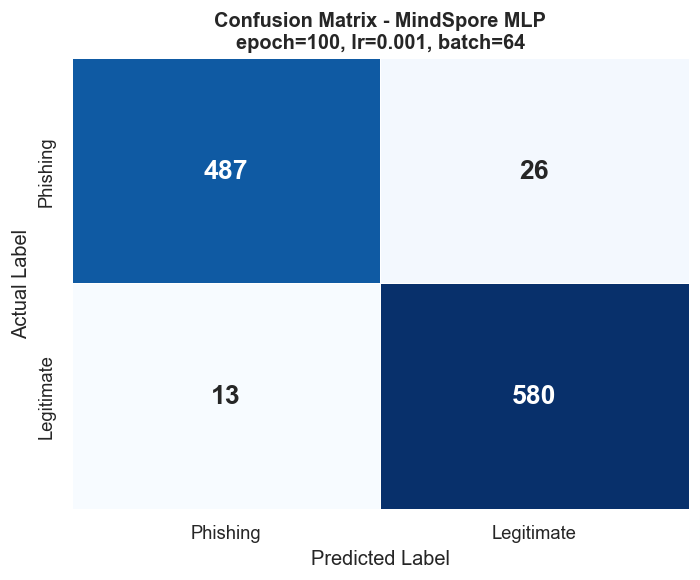

Figure 22 saved.


In [56]:
import sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

print(sklearn.__version__)

# Get predictions from best model
best_net = best_ms['model']
best_net.set_train(False)

logits_b  = best_net(X_te_t)
y_pred_ms = logits_b.asnumpy().argmax(axis=1)
y_true_ms = y_te_t.asnumpy()

acc_ms  = accuracy_score(y_true_ms, y_pred_ms)
prec_ms = precision_score(y_true_ms, y_pred_ms, pos_label=0, zero_division=0)
rec_ms  = recall_score(y_true_ms, y_pred_ms, pos_label=0, zero_division=0)
f1_ms   = f1_score(y_true_ms, y_pred_ms, pos_label=0, zero_division=0)
cm_ms   = confusion_matrix(y_true_ms, y_pred_ms)

print("=" * 60)
print(f"  MindSpore MLP — Best Tuned")
print(f"  epoch={best_ms['epoch']} | lr={best_ms['lr']} | batch={best_ms['batch_size']}")
print("=" * 60)
print(f"  Accuracy  : {acc_ms*100:.2f}%")
print(f"  Precision : {prec_ms*100:.2f}%")
print(f"  Recall    : {rec_ms*100:.2f}%  ← priority metric")
print(f"  F1-Score  : {f1_ms*100:.2f}%")
print()
print(classification_report(
    y_true_ms, y_pred_ms,
    target_names=['Phishing (0)', 'Legitimate (1)'],
    zero_division=0
))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_ms, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Phishing', 'Legitimate'],
    yticklabels=['Phishing', 'Legitimate'],
    linewidths=0.5, cbar=False,
    annot_kws={'size': 16, 'weight': 'bold'}
)
plt.title(
    f'Confusion Matrix - MindSpore MLP\n'
    f'epoch={best_ms["epoch"]}, lr={best_ms["lr"]}, batch={best_ms["batch_size"]}',
    fontweight='bold'
)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('fig22_cm_mindspore_mlp.png', bbox_inches='tight')
plt.show()
print("Figure 22 saved.")

### Step 42: Hyperparameter Accuracy Chart

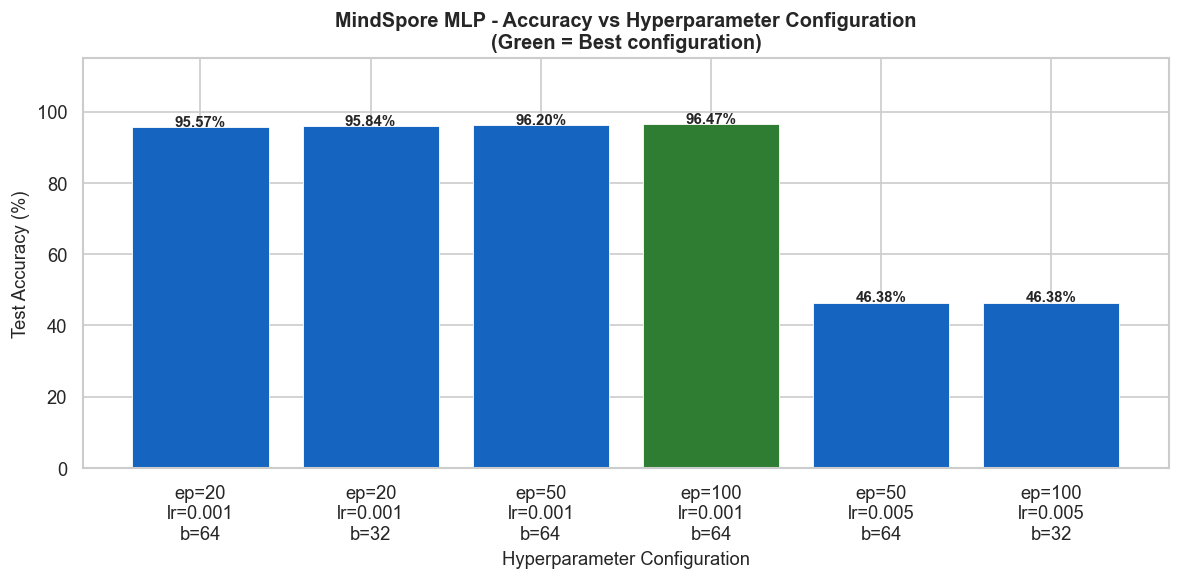

Figure 23 saved.


In [57]:
tuning_df_ms = pd.DataFrame([{
    'Config'  : f"ep={r['epoch']}\nlr={r['lr']}\nb={r['batch_size']}",
    'Accuracy': r['accuracy']*100
} for r in tuning_results_ms])

fig, ax = plt.subplots(figsize=(10, 5))
colors_ms = ['#2E7D32' if i == tuning_df_ms['Accuracy'].idxmax()
             else '#1565C0' for i in range(len(tuning_df_ms))]

bars = ax.bar(tuning_df_ms['Config'], tuning_df_ms['Accuracy'],
              color=colors_ms, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, tuning_df_ms['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Hyperparameter Configuration', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title(
    'MindSpore MLP - Accuracy vs Hyperparameter Configuration\n'
    '(Green = Best configuration)',
    fontweight='bold'
)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig('fig23_ms_hyperparameter_accuracy.png', bbox_inches='tight')
plt.show()
print("Figure 23 saved.")

## TASK 5 Final Summary & MindSpore Migration Checklist

### Step 43: Complete Project Summary

In [58]:
print("=" * 65)
print("  IT9201 - COMPLETE PROJECT SUMMARY")
print("  Phishing Website Detection Using Machine Learning")
print("=" * 65)
print()
print("  Student  : Fatema Husain Hasan")
print("  ID       : 202508958")
print()
print("  DATASET")
print("  ─────────────────────────────────────────────────")
print("  Source   : UCI Machine Learning Repository")
print("  Citation : Mohammad & McCluskey (2012)")
print("  DOI      : 10.24432/C51W2X")
print(f"  Rows     : {df.shape[0]:,}")
print(f"  Features : {df.shape[1]-1} (all numeric -1/0/1)")
print("  Balance  : 55.7% Legitimate / 44.3% Phishing")
print("  Missing  : 0")
print()
print("  FEATURE WORK ")
print("  ─────────────────────────────────────────────────")
print("  Selection  : Chi-Square - top 15 of 30 features")
print("  Extraction : PCA - visualisation + dimensionality")
print("  Engineering: URL_Risk_Score + Domain_Trust_Score")
print()
print("  SUPERVISED LEARNING RESULTS ")
print("  ─────────────────────────────────────────────────")
for r in all_results:
    print(f"  {r['name']:<44}"
          f"  Acc={r['accuracy']*100:.2f}%  F1={r['f1']*100:.2f}%")
best = max(all_results, key=lambda r: r['f1'])
print()
print(f"  Best Model : {best['name']}")
print(f"  Best F1    : {best['f1']*100:.2f}%")
print()
print("  UNSUPERVISED LEARNING ")
print("  ─────────────────────────────────────────────────")
print(f"  K-Means (k=2) Silhouette Score : {sil_final:.4f}")
print()
print("  ASSOCIATION RULE MINING ")
print("  ─────────────────────────────────────────────────")
print(f"  Frequent itemsets : {len(frequent_itemsets)}")
print(f"  Association rules : {len(rules)}")
print(f"  Note: Applied to phishing subset - finds co-occurring URL risk features")
print()
print("  MINDSPORE MIGRATION (Lab Manual)")
print("  ─────────────────────────────────────────────────")
print(f"  MindSpore version : {ms.__version__}")
print("  Pipeline followed : import ms → Tensor → NumpySlicesDataset")
print("                      → CSVClassifier(nn.Cell) → SoftmaxCrossEntropy")
print("                      → ms.Model → train → eval")
print(f"  Best MLP Accuracy : {best_ms['accuracy']*100:.2f}%")
print()
print("  DIFFERENTIATORS FROM CHAWLA (2022)")
print("  ─────────────────────────────────────────────────")
print("  1. Added unsupervised K-Means         (not in Chawla)")
print("  2. Chi-Square feature selection       (not in Chawla)")
print("  3. Orange no-code implementation      (not in Chawla)")
print("  4. MindSpore MLP migration            (not in Chawla)")
print("  5. Association rule mining            (not in Chawla)")
print()
print("=" * 65)
print("  End of Notebook — IT9201 Phishing Detection")
print("=" * 65)


  IT9201 - COMPLETE PROJECT SUMMARY
  Phishing Website Detection Using Machine Learning

  Student  : Fatema Husain Hasan
  ID       : 202508958

  DATASET
  ─────────────────────────────────────────────────
  Source   : UCI Machine Learning Repository
  Citation : Mohammad & McCluskey (2012)
  DOI      : 10.24432/C51W2X
  Rows     : 11,055
  Features : 30 (all numeric -1/0/1)
  Balance  : 55.7% Legitimate / 44.3% Phishing
  Missing  : 0

  FEATURE WORK 
  ─────────────────────────────────────────────────
  Selection  : Chi-Square - top 15 of 30 features
  Extraction : PCA - visualisation + dimensionality
  Engineering: URL_Risk_Score + Domain_Trust_Score

  SUPERVISED LEARNING RESULTS 
  ─────────────────────────────────────────────────
  KNN - Default (k=5)                           Acc=94.89%  F1=94.20%
  Decision Tree - Default                       Acc=97.11%  F1=96.72%
  KNN - Tuned (k=3)                             Acc=94.93%  F1=94.23%
  Decision Tree - Tuned (depth=None)      